Assignment 7:

Creating and Fixing Mode Collapse in a GAN

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras import layers

In [4]:
# Load MNIST dataset
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

# Normalize images to [-1, 1]
x_train = x_train.astype("float32")
x_train = (x_train - 127.5) / 127.5

# Add channel dimension
x_train = np.expand_dims(x_train, axis=-1)

# Create dataset
BATCH_SIZE = 128

dataset = tf.data.Dataset.from_tensor_slices(x_train)
dataset = dataset.shuffle(60000).batch(BATCH_SIZE)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
def create_generator():

    model = tf.keras.Sequential([
        layers.Dense(7 * 7 * 128, input_shape=(100,)),
        layers.Reshape((7, 7, 128)),

        layers.Conv2DTranspose(64, 4, strides=2, padding="same"),
        layers.LeakyReLU(0.2),

        layers.Conv2DTranspose(1, 4, strides=2, padding="same"),
        layers.Activation("tanh")
    ])

    return model

In [6]:
def create_discriminator():

    model = tf.keras.Sequential([
        layers.Conv2D(64, 4, strides=2, padding="same",
                      input_shape=(28, 28, 1)),
        layers.LeakyReLU(0.2),

        layers.Conv2D(128, 4, strides=2, padding="same"),
        layers.LeakyReLU(0.2),

        layers.Flatten(),
        layers.Dense(1)
    ])

    return model

In [7]:
generator = create_generator()
discriminator = create_discriminator()

# Very high learning rate to make training unstable
generator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.01,
    beta_1=0.5
)

discriminator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.01,
    beta_1=0.5
)

loss_function = tf.keras.losses.BinaryCrossentropy(from_logits=True)

EPOCHS = 15
NOISE_DIM = 100

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
@tf.function
def train_step(images):

    noise = tf.random.normal([tf.shape(images)[0], NOISE_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = loss_function(
            tf.ones_like(fake_output),
            fake_output
        )

        disc_loss_real = loss_function(
            tf.ones_like(real_output),
            real_output
        )

        disc_loss_fake = loss_function(
            tf.zeros_like(fake_output),
            fake_output
        )

        disc_loss = disc_loss_real + disc_loss_fake

    gen_gradients = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    disc_gradients = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    generator_optimizer.apply_gradients(
        zip(gen_gradients, generator.trainable_variables)
    )

    discriminator_optimizer.apply_gradients(
        zip(disc_gradients, discriminator.trainable_variables)
    )

    return gen_loss, disc_loss

In [9]:
for epoch in range(EPOCHS):

    for batch in dataset:
        gen_loss, disc_loss = train_step(batch)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Generator Loss: {gen_loss:.4f} | "
        f"Discriminator Loss: {disc_loss:.4f}"
    )

Epoch 1/15 | Generator Loss: 13.0357 | Discriminator Loss: 0.3515
Epoch 2/15 | Generator Loss: 7.1273 | Discriminator Loss: 0.0123
Epoch 3/15 | Generator Loss: 10.1330 | Discriminator Loss: 0.0375
Epoch 4/15 | Generator Loss: 9.5218 | Discriminator Loss: 0.0019
Epoch 5/15 | Generator Loss: 11.5129 | Discriminator Loss: 0.0003
Epoch 6/15 | Generator Loss: 12.6653 | Discriminator Loss: 0.0000
Epoch 7/15 | Generator Loss: 10.8149 | Discriminator Loss: 0.0002
Epoch 8/15 | Generator Loss: 191.1241 | Discriminator Loss: 18.9618
Epoch 9/15 | Generator Loss: 116.4656 | Discriminator Loss: 0.6368
Epoch 10/15 | Generator Loss: 48.5897 | Discriminator Loss: 0.1827
Epoch 11/15 | Generator Loss: 57.3137 | Discriminator Loss: 0.0361
Epoch 12/15 | Generator Loss: 133.7645 | Discriminator Loss: 0.7152
Epoch 13/15 | Generator Loss: 70.9233 | Discriminator Loss: 0.0001
Epoch 14/15 | Generator Loss: 165.7237 | Discriminator Loss: 0.0999
Epoch 15/15 | Generator Loss: 150.9346 | Discriminator Loss: 0.0000


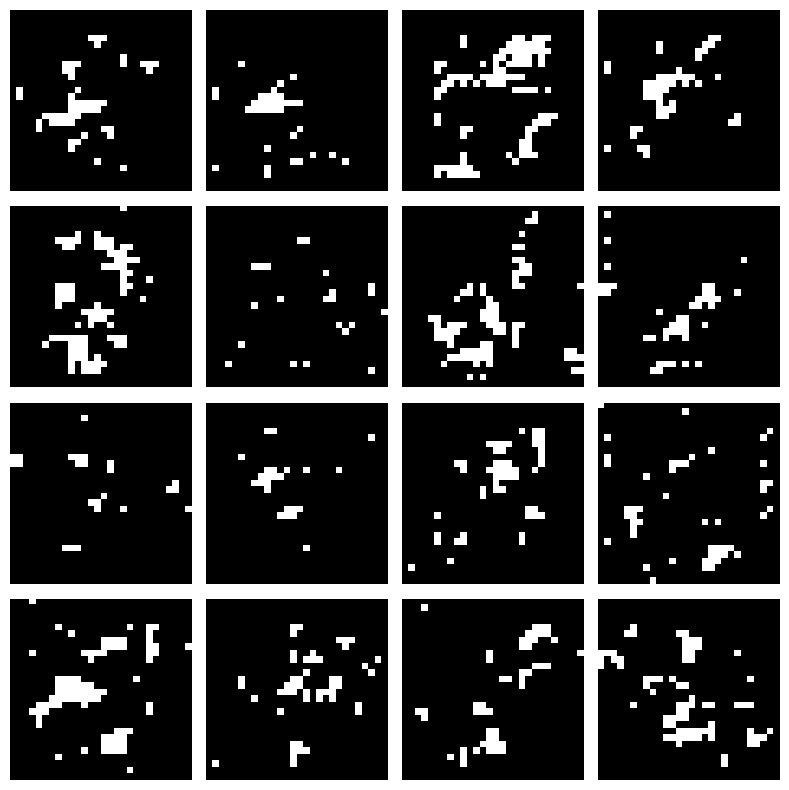

In [10]:
def generate_images(model, filename):

    noise = tf.random.normal([16, NOISE_DIM])

    predictions = model(noise, training=False)

    predictions = (predictions + 1) / 2.0

    plt.figure(figsize=(8, 8))

    for i in range(16):
        plt.subplot(4, 4, i + 1)
        plt.imshow(predictions[i, :, :, 0], cmap="gray")
        plt.axis("off")

    plt.tight_layout()
    plt.savefig(filename)
    plt.show()


generate_images(
    generator,
    "broken_mode_collapse.png"
)

In [11]:
generator2 = create_generator()
discriminator2 = create_discriminator()

generator_optimizer2 = tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

discriminator_optimizer2 = tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

In [12]:
@tf.function
def train_step_improved(images):

    noise = tf.random.normal([tf.shape(images)[0], NOISE_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

        generated_images = generator2(noise, training=True)

        real_output = discriminator2(images, training=True)
        fake_output = discriminator2(generated_images, training=True)

        gen_loss = loss_function(
            tf.ones_like(fake_output),
            fake_output
        )

        # Label smoothing:
        # Real labels are changed from 1.0 to 0.9
        real_labels = tf.ones_like(real_output) * 0.9

        disc_loss_real = loss_function(
            real_labels,
            real_output
        )

        disc_loss_fake = loss_function(
            tf.zeros_like(fake_output),
            fake_output
        )

        disc_loss = disc_loss_real + disc_loss_fake

    gen_gradients = gen_tape.gradient(
        gen_loss,
        generator2.trainable_variables
    )

    disc_gradients = disc_tape.gradient(
        disc_loss,
        discriminator2.trainable_variables
    )

    generator_optimizer2.apply_gradients(
        zip(gen_gradients, generator2.trainable_variables)
    )

    discriminator_optimizer2.apply_gradients(
        zip(disc_gradients, discriminator2.trainable_variables)
    )

    return gen_loss, disc_loss

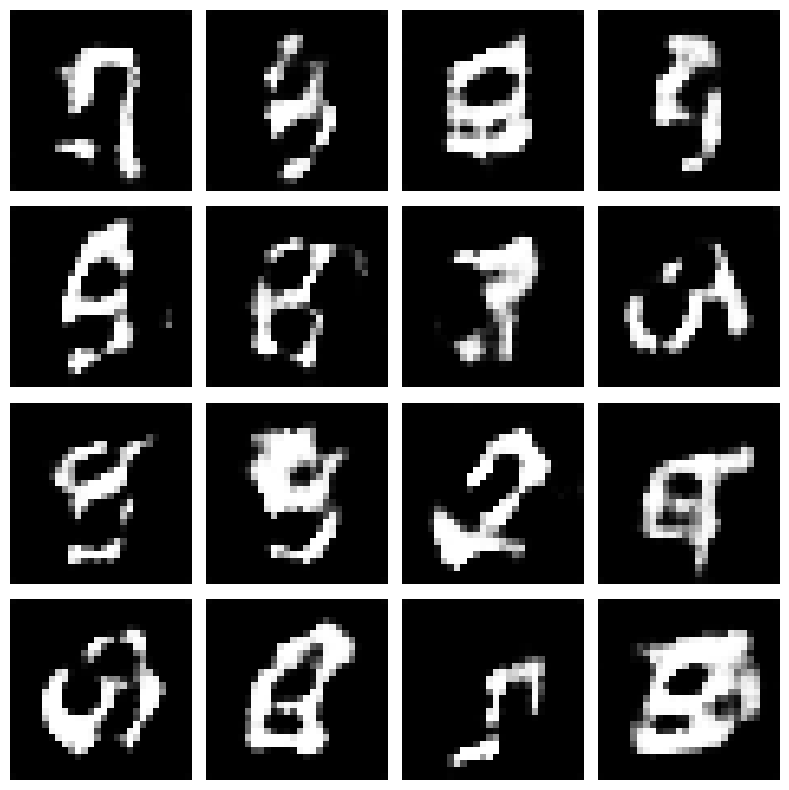

In [14]:
for epoch in range(1):
    for batch in dataset.take(20):
        gen_loss, disc_loss = train_step_improved(batch)

generate_images(generator2, "improved_output.png")

Conclusion

This experiment demonstrated that unstable GAN training can cause mode collapse. Using label smoothing and a more suitable learning rate helped stabilize the training process and improve the diversity of generated images.